In [ ]:
# Part A: Imports & Data Loading
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("LoanApprovalPrediction.csv")
df.head()

In [ ]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Missing values
print("\nMissing values:")
print(df.isna().sum())

# Basic statistics
df.describe(include='all')

#Basic outlier check (for information)
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

print("\nOutlier counts (IQR method):")
for col in numeric_cols:
    print(f"{col}: {count_outliers_iqr(df[col].dropna())} outliers")


In [ ]:
df = df.drop('Loan_ID',axis=1)


In [7]:
columns = ['Gender','Dependents','LoanAmount','Loan_Amount_Term','Credit_History']
df = df.dropna(subset=columns)


In [8]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [10]:
df['Dependents'] =df['Dependents'].replace(to_replace="3+",value='4')


In [12]:
df['Dependents'].unique()


array([1., 0., 2., 3.])

In [13]:
df['Loan_Status'].unique()


array(['N', 'Y'], dtype=object)

In [14]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0}).astype('int')
df['Married'] = df['Married'].map({'Yes':1,'No':0}).astype('int')
df['Education'] = df['Education'].map({'Graduate':1,'Not Graduate':0}).astype('int')
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1,'No':0}).astype('int')
df['Property_Area'] = df['Property_Area'].map({'Rural':0,'Semiurban':2,'Urban':1}).astype('int')
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0}).astype('int')

In [15]:
df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,1,1
5,1,1,2.0,1,1,5417,4196.0,267.0,360.0,1.0,1,1


In [16]:
X = df.drop('Loan_Status',axis=1)
y = df['Loan_Status']


# Part B: Exploratory Data Analysis

## Univariate Analysis

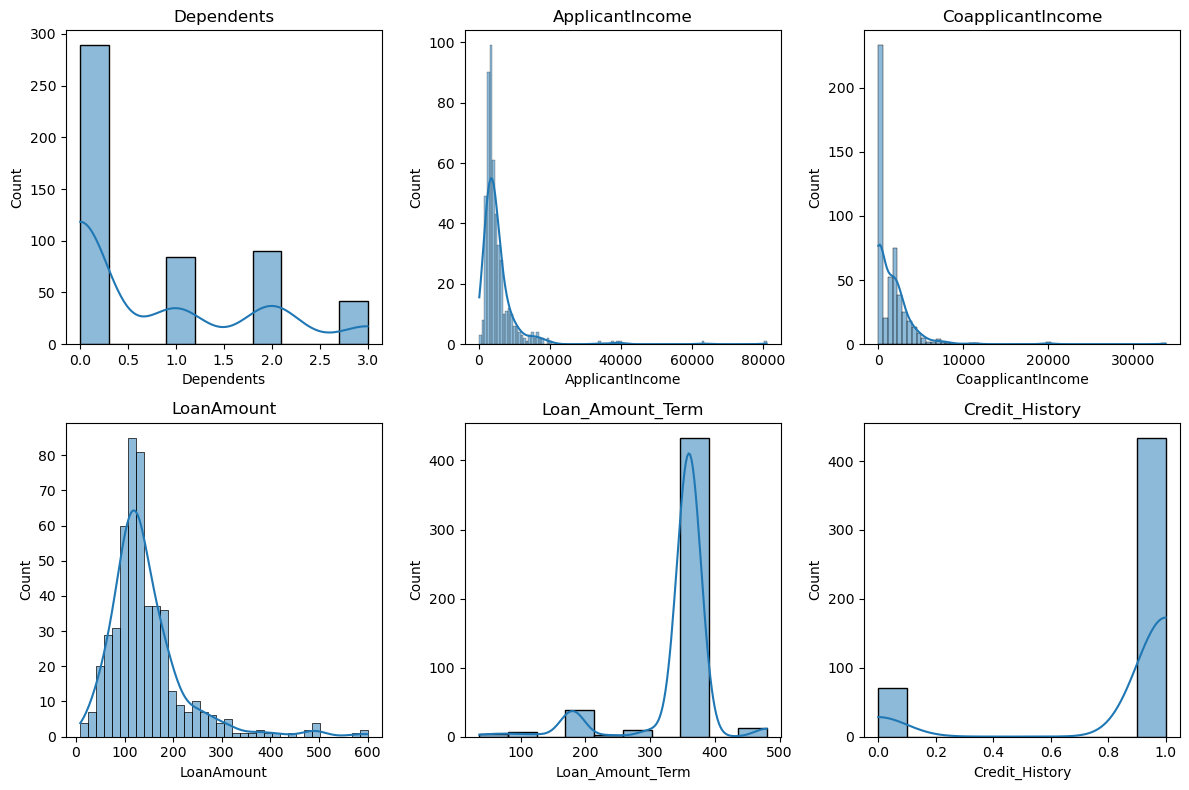

In [17]:
# Histograms for numeric variables
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

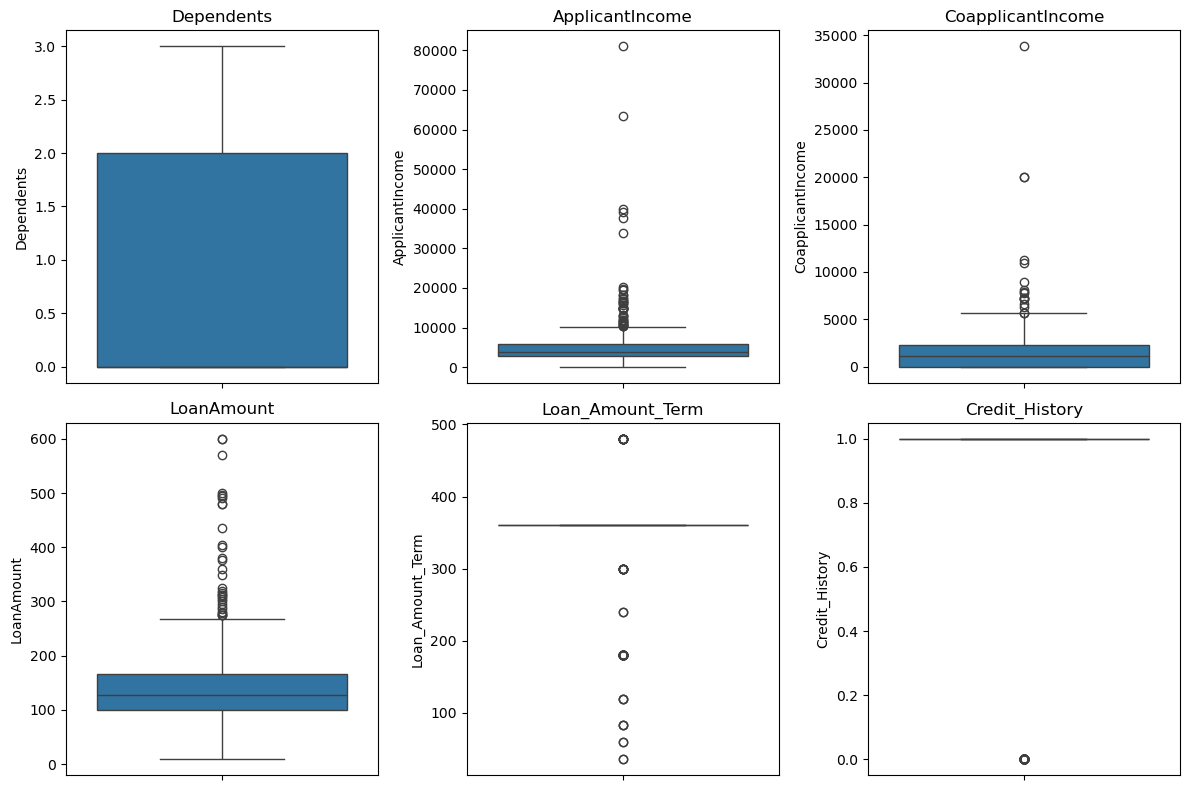

In [18]:
# Boxplots to spot outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [19]:
# Key statistics + skewness
stats_summary = df[numeric_cols].agg(['mean', 'median']).T
stats_summary['skewness'] = df[numeric_cols].skew()
stats_summary

,mean,median,skewness
Dependents,0.772277,0.0,0.945832
ApplicantIncome,5411.427723,3833.0,6.865884
CoapplicantIncome,1562.978059,1126.0,5.957924
LoanAmount,144.566337,128.0,2.392255
Loan_Amount_Term,341.869307,360.0,-2.333349
Credit_History,0.859406,1.0,-2.074080


In [26]:
def iqr_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower, lower,
                           np.where(df[column] > upper, upper, df[column]))
    return df

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    df = iqr_capping(df, col)


In [27]:
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['CoapplicantIncome_log'] = np.log1p(df['CoapplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])


df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0]).astype(int)
df['Credit_History'] = df['Credit_History'].fillna(1).astype(int)



In [28]:
# Key statistics + skewness
stats_summary = df[numeric_cols].agg(['mean', 'median']).T
stats_summary['skewness'] = df[numeric_cols].skew()
stats_summary

,mean,median,skewness
Dependents,0.772277,0.0,0.945832
ApplicantIncome,4650.930693,3833.0,1.038236
CoapplicantIncome,1392.563208,1126.0,1.023973
LoanAmount,137.423762,128.0,0.675856
Loan_Amount_Term,341.869307,360.0,-2.333349
Credit_History,0.859406,1.0,-2.074080


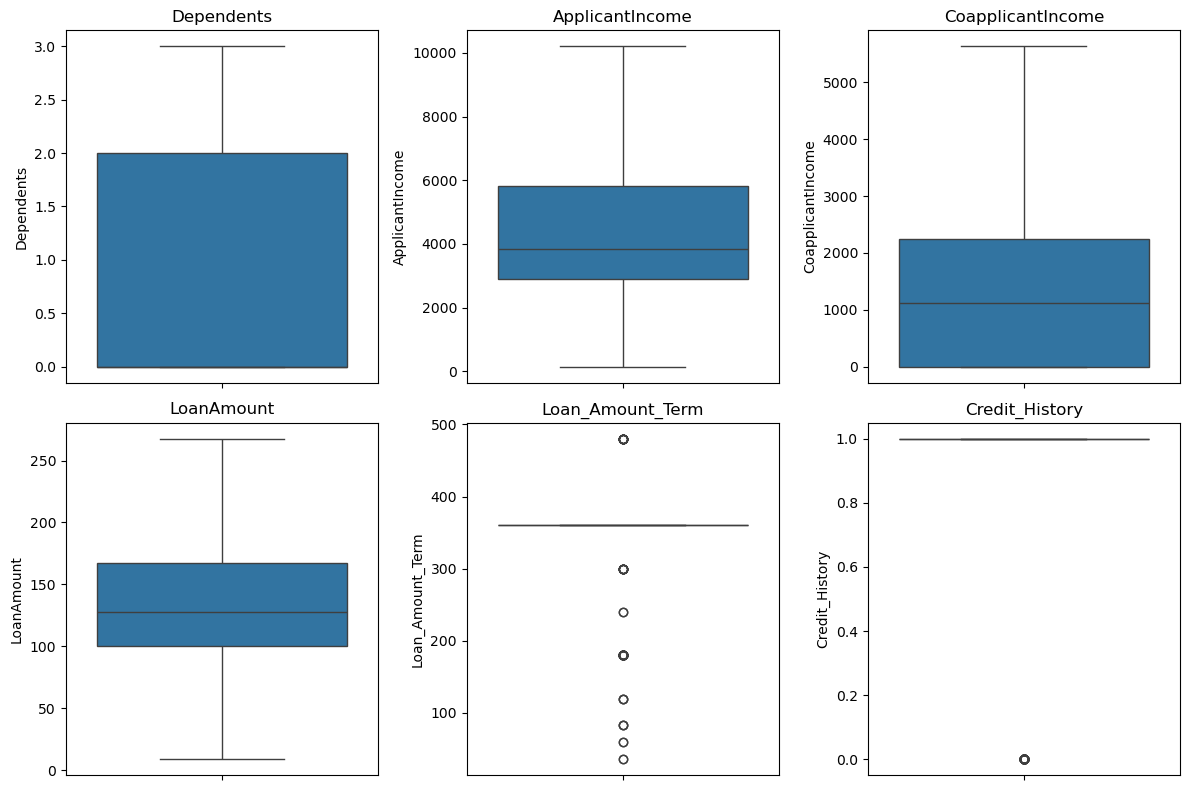

In [30]:
# Boxplots to spot outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['ApplicantIncome_final','CoapplicantIncome_final','LoanAmount_final']] = scaler.fit_transform(
        df[['ApplicantIncome','CoapplicantIncome','LoanAmount']])


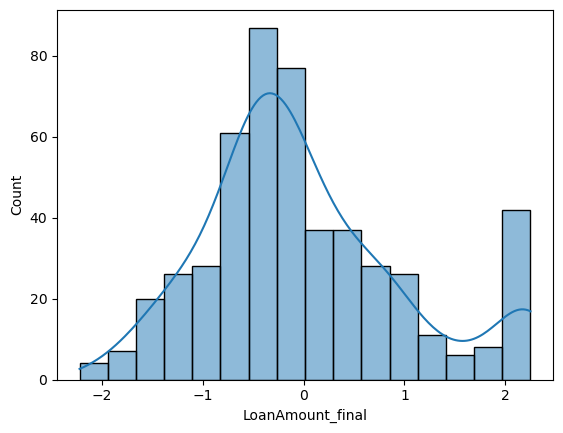

Skewness: ApplicantIncome_final      1.038236
CoapplicantIncome_final    1.023973
LoanAmount_final           0.675856
dtype: float64


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['LoanAmount_final'], kde=True)
plt.show()

print("Skewness:",
      df[['ApplicantIncome_final',
          'CoapplicantIncome_final',
          'LoanAmount_final']].skew())


## Bivariate Analysis

In [21]:
features = ['Gender', 'Married', 'Dependents','Education', 'Self_Employed','ApplicantIncome','CoapplicantIncome','LoanAmount',
           'Loan_Amount_Term','Credit_History','Property_Area']
target = 'Loan_Status'

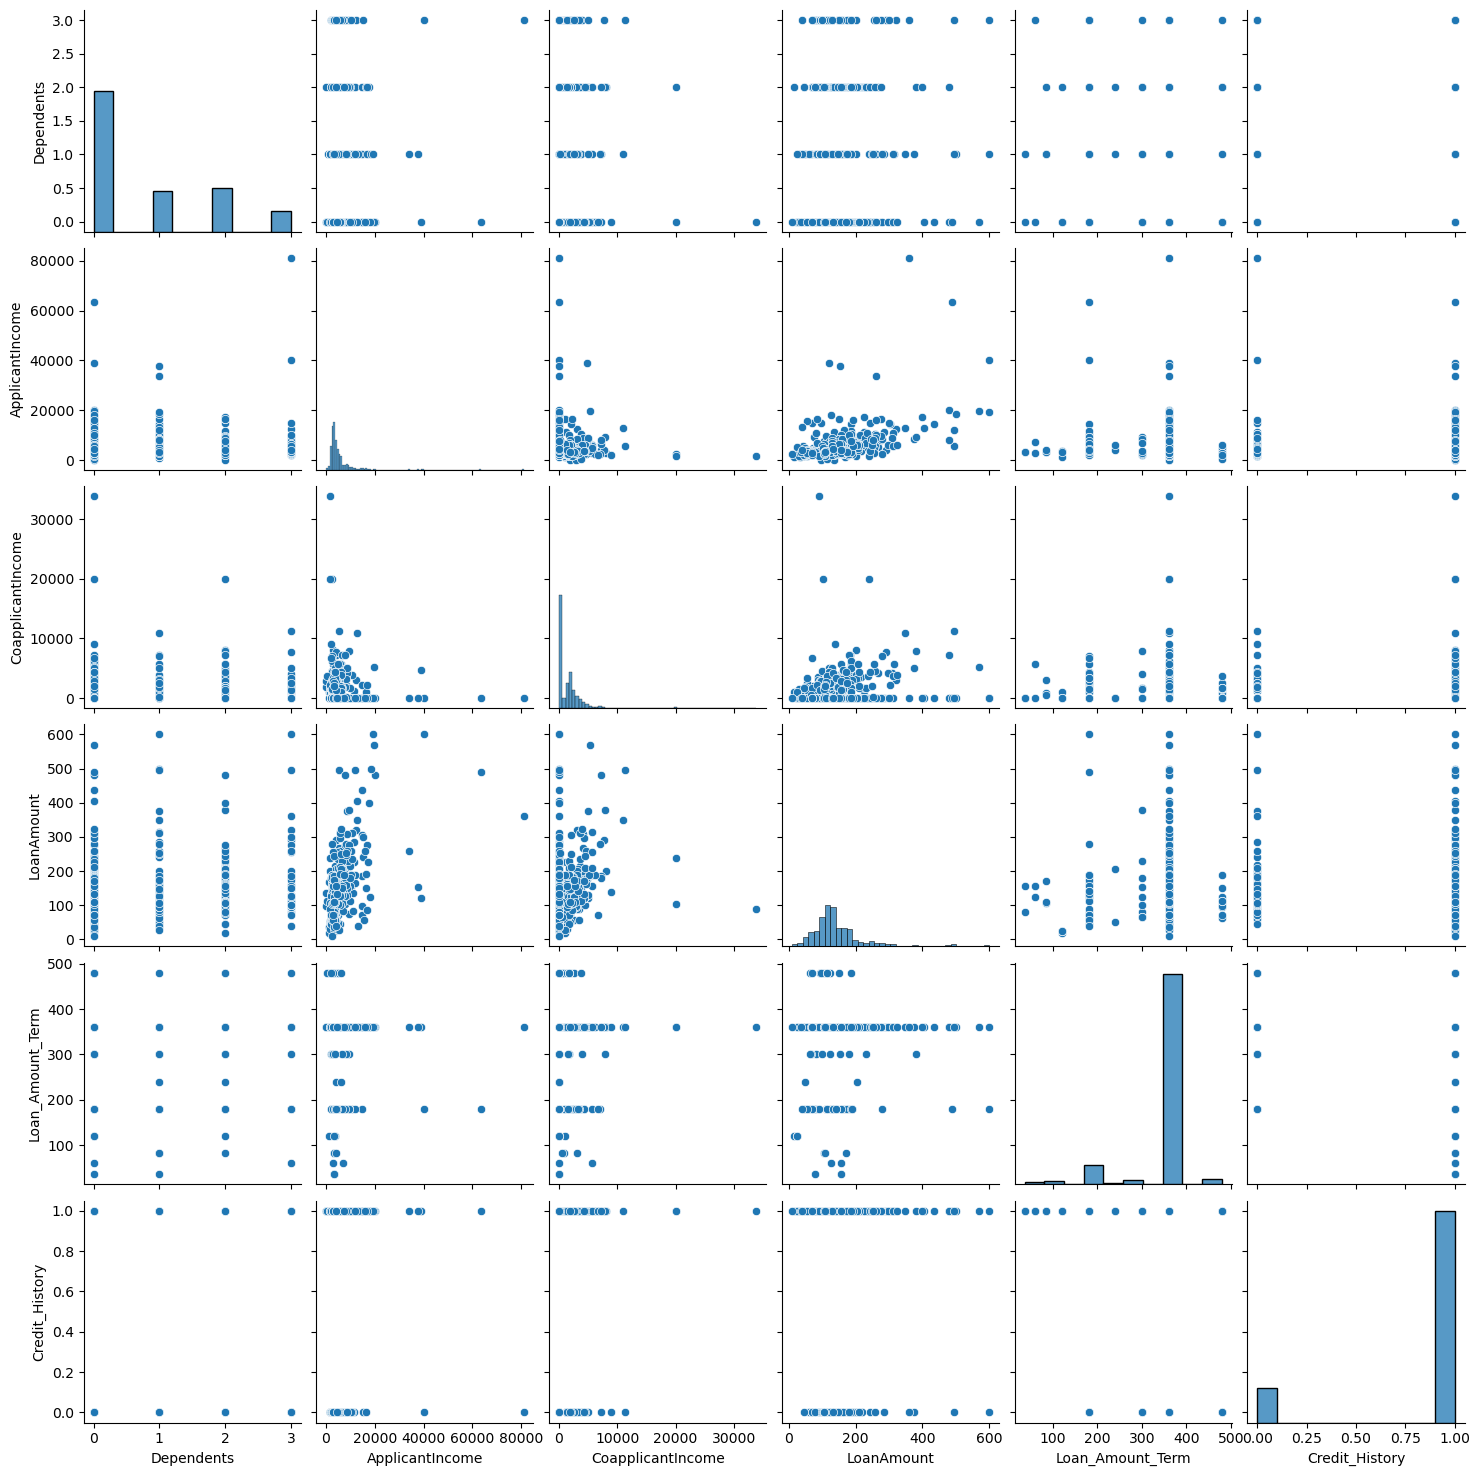

In [23]:
sns.pairplot(df[numeric_cols])
plt.show()

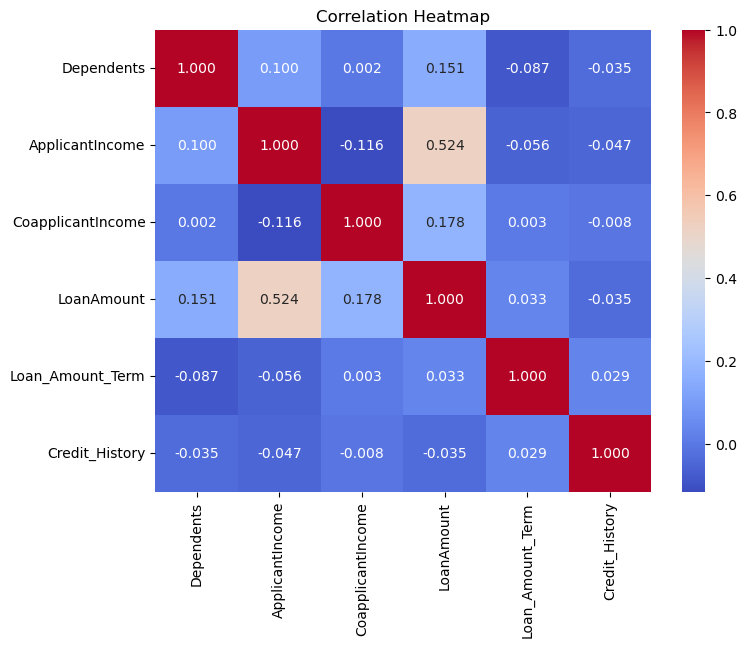

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Dependents,1.000000,0.099684,0.001946,0.150881,-0.086525,-0.034602
ApplicantIncome,0.099684,1.000000,-0.115651,0.523904,-0.056474,-0.046667
CoapplicantIncome,0.001946,-0.115651,1.000000,0.178145,0.002571,-0.007905
LoanAmount,0.150881,0.523904,0.178145,1.000000,0.033250,-0.034702
Loan_Amount_Term,-0.086525,-0.056474,0.002571,0.033250,1.000000,0.029234
Credit_History,-0.034602,-0.046667,-0.007905,-0.034702,0.029234,1.000000


In [24]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

corr

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select independent variables
X = df[['Dependents',
        'ApplicantIncome_final',
        'CoapplicantIncome_final',
        'LoanAmount_final',
        'Loan_Amount_Term',
        'Credit_History']]

# Add constant
X = X.assign(constant=1)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data


,Feature,VIF
0,Dependents,1.040460
1,ApplicantIncome_final,1.977498
2,CoapplicantIncome_final,1.419278
3,LoanAmount_final,2.076198
4,Loan_Amount_Term,1.030852
5,Credit_History,1.004302
6,constant,36.497032


In [42]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, r2_score
)
import numpy as np

model_df = {}

def model_val(model, X, y):
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probabilities (for AUC metrics)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # -------- Classification Metrics --------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    

  
    # -------- Cross Validation --------
    cv_score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    # -------- Print results --------
    print(f"\nModel: {model.__class__.__name__}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC ROC   : {auc_roc:.4f}")
    print(f"AUC PR    : {auc_pr:.4f}")
    print(f"CV Acc   : {cv_score:.4f}")

    # -------- Store results --------
    model_df[model.__class__.__name__] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "CV_Accuracy": cv_score
    }


In [43]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model_val(model,X,y)

C:\Users\A\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che


Model: LogisticRegression
Accuracy  : 0.8119
Precision : 0.8095
Recall    : 0.9577
F1 Score  : 0.8774
AUC ROC   : 0.7948
AUC PR    : 0.8590
CV Acc   : 0.8119


C:\Users\A\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che

In [44]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model_val(model,X,y)


Model: DecisionTreeClassifier
Accuracy  : 0.6931
Precision : 0.7941
Recall    : 0.7606
F1 Score  : 0.7770
AUC ROC   : 0.6545
AUC PR    : 0.7750
CV Acc   : 0.7287


In [45]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model_val(model,X,y)


Model: RandomForestClassifier
Accuracy  : 0.8218
Precision : 0.8354
Recall    : 0.9296
F1 Score  : 0.8800
AUC ROC   : 0.7955
AUC PR    : 0.8939
CV Acc   : 0.8059
